In [12]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import os

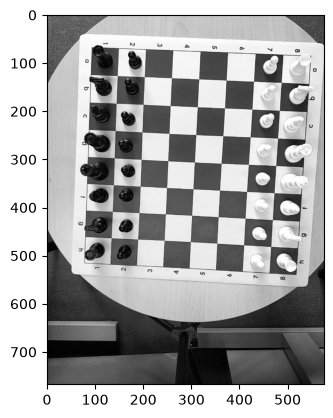

In [13]:
image_path = '../samples/screenshot.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')

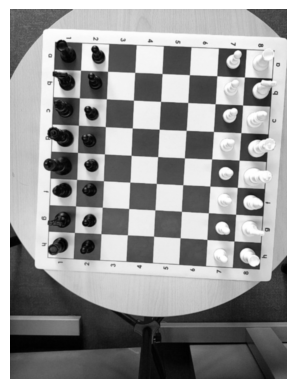

In [14]:
blurred = cv2.GaussianBlur(gray, (3, 3), 0)
plt.imshow(blurred, cmap='gray')
plt.axis('off')
plt.show()

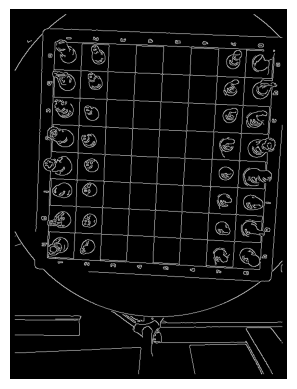

In [15]:
edges = cv2.Canny(blurred, 50, 150)
margin = 10
edges[:margin, :] = 0
edges[-margin:, :] = 0
edges[:, :margin] = 0
edges[:, -margin:] = 0


plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

In [16]:
def fit_chessboard_grid(image, max_corners=500, debug=False):

    if image is None:
        raise ValueError("image is None")

    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        dbg = image.copy()
    else:
        gray = image.copy()
        dbg = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    # ------------------------------------------------------------
    # 1) detect candidate corners
    # ------------------------------------------------------------
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    pts = cv2.goodFeaturesToTrack(
        blur,
        maxCorners=500,
        qualityLevel=0.01,
        minDistance=6,
        blockSize=5,
        useHarrisDetector=True,
        k=0.04
    )

    if pts is None or len(pts) < 25:
        return (None, dbg) if debug else None

    pts = pts[:, 0, :].astype(np.float32)

    term = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.01)
    pts = cv2.cornerSubPix(gray, pts, (5, 5), (-1, -1), term)

    # ------------------------------------------------------------
    # 2) estimate two dominant lattice directions from local pair angles
    # ------------------------------------------------------------
    angle_hist = np.zeros(180, dtype=np.float32)
    radius = max(gray.shape[:2]) * 0.15

    for i in range(len(pts)):
        pi = pts[i]
        for j in range(i + 1, len(pts)):
            pj = pts[j]
            dvec = pj - pi
            d = np.linalg.norm(dvec)
            if d < 5 or d > radius:
                continue
            ang = np.degrees(np.arctan2(dvec[1], dvec[0]))
            ang = (ang + 180) % 180
            angle_hist[int(ang)] += 1.0 / (1.0 + d)

    if angle_hist.max() == 0:
        return (None, dbg) if debug else None

    # smooth histogram
    smooth = np.zeros_like(angle_hist)
    for i in range(180):
        for k in range(-4, 5):
            smooth[i] += angle_hist[(i + k) % 180]

    a1 = int(np.argmax(smooth))
    smooth2 = smooth.copy()
    for k in range(-20, 21):
        smooth2[(a1 + k) % 180] = 0
    a2 = int(np.argmax(smooth2))

    th1 = np.deg2rad(a1)
    th2 = np.deg2rad(a2)

    u1 = np.array([np.cos(th1), np.sin(th1)], dtype=np.float32)
    u2 = np.array([np.cos(th2), np.sin(th2)], dtype=np.float32)

    if abs(np.cross(u1, u2)) < 0.25:
        return (None, dbg) if debug else None

    # ------------------------------------------------------------
    # 3) transform points into lattice basis
    # ------------------------------------------------------------
    A = np.stack([u1, u2], axis=1)
    try:
        Ainv = np.linalg.inv(A)
    except np.linalg.LinAlgError:
        return (None, dbg) if debug else None

    uv = (Ainv @ pts.T).T

    # ------------------------------------------------------------
    # 4) estimate lattice spacings
    # ------------------------------------------------------------
    du_vals = []
    dv_vals = []

    for i in range(len(uv)):
        for j in range(i + 1, len(uv)):
            d = uv[j] - uv[i]
            adu = abs(d[0])
            adv = abs(d[1])

            if adv < 8 and adu > 4:
                du_vals.append(adu)
            if adu < 8 and adv > 4:
                dv_vals.append(adv)

    if len(du_vals) < 20 or len(dv_vals) < 20:
        return (None, dbg) if debug else None

    def dominant_spacing(vals):
        vals = np.array(vals, dtype=np.float32)
        vals = vals[(vals > 4) & (vals < np.percentile(vals, 85))]
        if len(vals) < 10:
            return None
        hist, edges = np.histogram(vals, bins=100)
        k = np.argmax(hist)
        return 0.5 * (edges[k] + edges[k + 1])

    su = dominant_spacing(du_vals)
    sv = dominant_spacing(dv_vals)

    if su is None or sv is None:
        return (None, dbg) if debug else None

    # ------------------------------------------------------------
    # 5) try many lattice origins and score 9x9 occupancy
    # ------------------------------------------------------------
    best_score = -1
    best_params = None
    best_assign = None

    u_all = uv[:, 0]
    v_all = uv[:, 1]

    # sample possible origins from actual points
    sample_idx = np.linspace(0, len(pts) - 1, min(80, len(pts))).astype(int)

    for idx in sample_idx:
        u0 = u_all[idx]
        v0 = v_all[idx]

        iu = np.round((u_all - u0) / su).astype(int)
        iv = np.round((v_all - v0) / sv).astype(int)

        # try sliding 9x9 windows in integer lattice space
        for umin in range(iu.min(), iu.max() - 7):
            umax = umin + 8
            for vmin in range(iv.min(), iv.max() - 7):
                vmax = vmin + 8

                inside = (iu >= umin) & (iu <= umax) & (iv >= vmin) & (iv <= vmax)
                if inside.sum() < 20:
                    continue

                # occupancy map
                occ = {}
                residuals = []

                for p, a, b, keep, uu, vv in zip(pts, iu, iv, inside, u_all, v_all):
                    if not keep:
                        continue
                    key = (a, b)
                    pred_u = u0 + a * su
                    pred_v = v0 + b * sv
                    residuals.append((uu - pred_u) ** 2 + (vv - pred_v) ** 2)
                    if key not in occ:
                        occ[key] = []
                    occ[key].append(p)

                # count occupied cells in 9x9
                occ_count = 0
                for a in range(umin, umax + 1):
                    for b in range(vmin, vmax + 1):
                        if (a, b) in occ:
                            occ_count += 1

                if occ_count < 20:
                    continue

                residual = np.mean(residuals) if residuals else 1e9

                # encourage occupancy, penalize fitting error
                score = occ_count * 10 - residual

                # bonus for interior support
                interior = 0
                for a in range(umin + 1, umax):
                    for b in range(vmin + 1, vmax):
                        if (a, b) in occ:
                            interior += 1
                score += interior * 4

                if score > best_score:
                    best_score = score
                    best_params = (u0, v0, umin, vmin)
                    best_assign = occ

    if best_params is None:
        return (None, dbg) if debug else None

    u0, v0, umin, vmin = best_params

    # ------------------------------------------------------------
    # 6) build predicted 9x9 grid and refine with observed points
    # ------------------------------------------------------------
    grid = np.zeros((9, 9, 2), dtype=np.float32)

    for r in range(9):
        for c in range(9):
            a = umin + c
            b = vmin + r

            pred_uv = np.array([u0 + a * su, v0 + b * sv], dtype=np.float32)
            pred_xy = A @ pred_uv

            if (a, b) in best_assign:
                obs = np.mean(best_assign[(a, b)], axis=0)
                # blend observed and predicted for stability
                pt = 0.7 * obs + 0.3 * pred_xy
            else:
                pt = pred_xy

            grid[r, c] = pt

    # ------------------------------------------------------------
    # 7) optional homography refinement from ideal lattice
    # ------------------------------------------------------------
    src = []
    dst = []
    for r in range(9):
        for c in range(9):
            a = umin + c
            b = vmin + r
            if (a, b) in best_assign:
                obs = np.mean(best_assign[(a, b)], axis=0)
                src.append([c, r])
                dst.append(obs)

    if len(src) >= 8:
        src = np.array(src, dtype=np.float32)
        dst = np.array(dst, dtype=np.float32)

        H, mask = cv2.findHomography(src, dst, method=cv2.RANSAC, ransacReprojThreshold=5.0)
        if H is not None:
            ideal = np.array([[[c, r]] for r in range(9) for c in range(9)], dtype=np.float32)
            proj = cv2.perspectiveTransform(ideal, H).reshape(9, 9, 2)
            grid = proj.astype(np.float32)

    # ------------------------------------------------------------
    # debug draw
    # ------------------------------------------------------------
    if debug:
        for p in pts:
            cv2.circle(dbg, tuple(np.int32(p)), 2, (120, 120, 120), -1)

        for r in range(9):
            for c in range(9):
                p = tuple(np.int32(grid[r, c]))
                cv2.circle(dbg, p, 4, (0, 255, 255), -1)

        for r in range(9):
            for c in range(8):
                p1 = tuple(np.int32(grid[r, c]))
                p2 = tuple(np.int32(grid[r, c + 1]))
                cv2.line(dbg, p1, p2, (0, 255, 0), 1)

        for c in range(9):
            for r in range(8):
                p1 = tuple(np.int32(grid[r, c]))
                p2 = tuple(np.int32(grid[r + 1, c]))
                cv2.line(dbg, p1, p2, (255, 0, 0), 1)

        return grid, dbg

    return grid

/tmp/ipykernel_37750/686050879.py:75: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if abs(np.cross(u1, u2)) < 0.25:


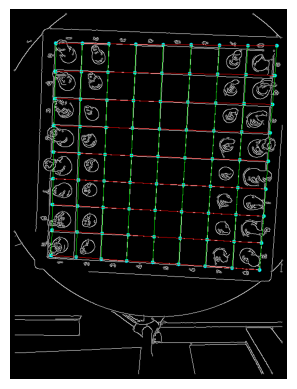

Grid shape: (9, 9, 2)


In [17]:
grid, dbg = fit_chessboard_grid(edges, debug=True)

plt.imshow(dbg)
plt.axis('off')
plt.show()
print("Grid shape:", None if grid is None else grid.shape)

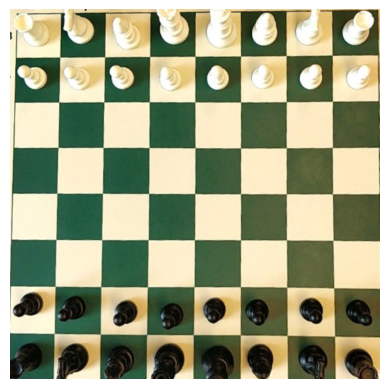

In [18]:
src = np.array([
    grid[0, 0],
    grid[0, 8],
    grid[8, 8],
    grid[8, 0]
], dtype=np.float32)

dst = np.array([
    [0, 0],
    [640 - 1, 0],
    [640 - 1, 640 - 1],
    [0, 640 - 1]
], dtype=np.float32)

M = cv2.getPerspectiveTransform(src, dst)
warped = cv2.warpPerspective(image, M, (640, 640), flags=cv2.INTER_LINEAR)

plt.imshow(warped)
plt.axis('off')
plt.show()